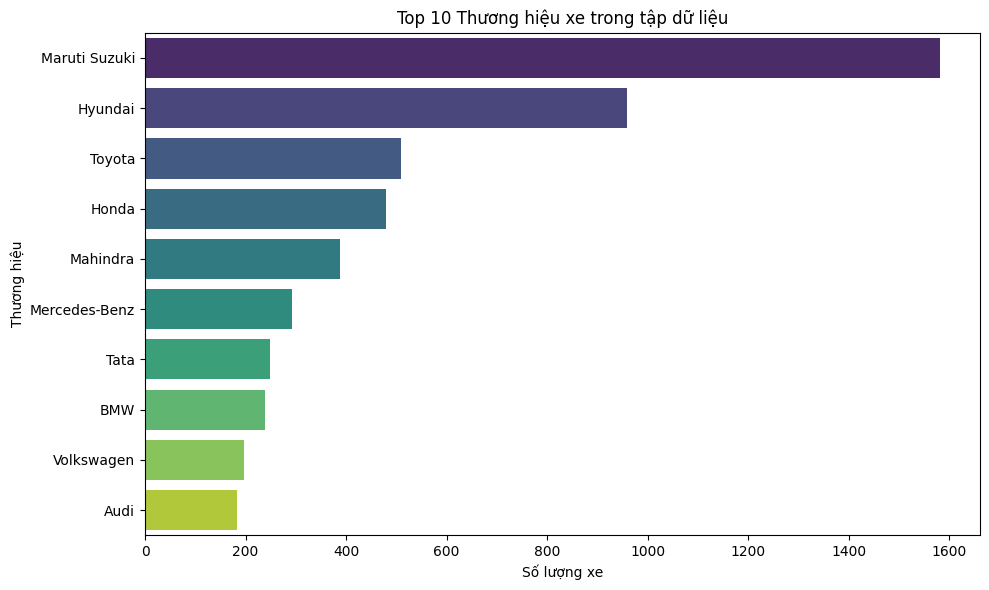

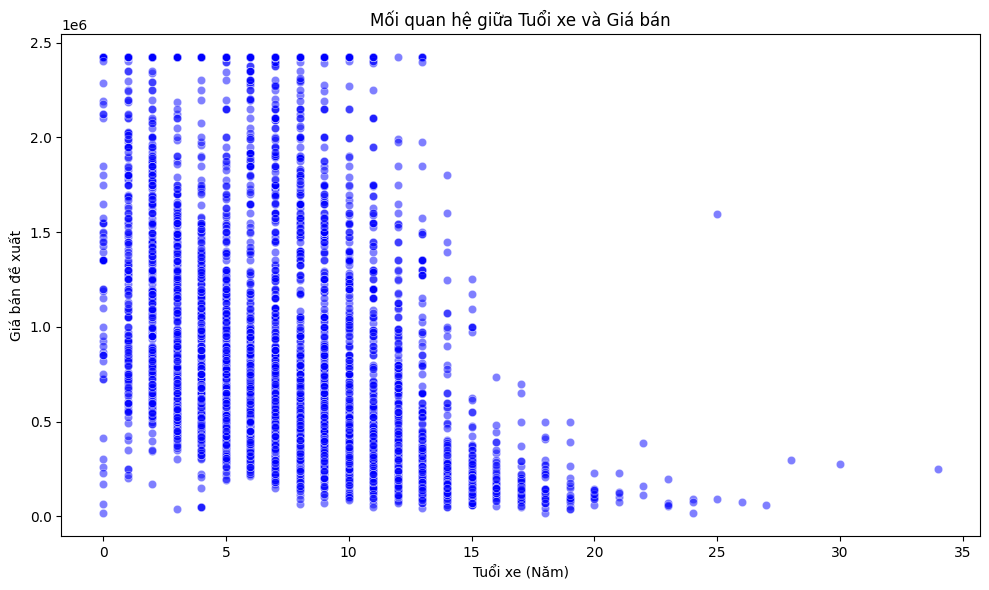

<function print>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV
df = pd.read_csv('Data_CarPrice.csv')

# Biểu đồ 1: Top 10 Thương hiệu xe
plt.figure(figsize=(10, 6))
top_brands = df['Brand'].value_counts().head(10)

# Cập nhật code để sửa cảnh báo: thêm hue=top_brands.index và legend=False
sns.barplot(
    x=top_brands.values, 
    y=top_brands.index, 
    hue=top_brands.index,   
    palette='viridis', 
    legend=False             
)

plt.title('Top 10 Thương hiệu xe trong tập dữ liệu')
plt.xlabel('Số lượng xe')
plt.ylabel('Thương hiệu')
plt.tight_layout()
plt.show()

# Biểu đồ 2: Mối quan hệ giữa Tuổi xe và Giá bán (Scatter Plot) 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='AskPrice', alpha=0.5, color='blue')
plt.title('Mối quan hệ giữa Tuổi xe và Giá bán')
plt.xlabel('Tuổi xe (Năm)')
plt.ylabel('Giá bán đề xuất')
plt.tight_layout()
plt.show()
print

In [3]:
#  Elastic Net Regression Custom 
import pandas as pd
import numpy as np
import pickle

from preprocess import clean_data, handle_outliers_iqr
from encoding import fit_target_encoder, transform_target_encoder
from elasticnet import StandardScaler, ElasticNetCD, train_test_split
# Load & Clean
df = pd.read_csv("Data_CarPrice.csv")
df = clean_data(df)

numeric_cols = ['AskPrice', 'kmDriven', 'km_per_year']
df = handle_outliers_iqr(df, numeric_cols)

# Split before encoding
X = df.drop(columns=['AskPrice'])
y = df['AskPrice']


X_train_np, X_test_np, y_train_M, y_test_M = train_test_split(X.values, y.values)

# Convert lại DataFrame
columns_raw = X.columns
X_train = pd.DataFrame(X_train_np, columns=columns_raw)
X_test  = pd.DataFrame(X_test_np, columns=columns_raw)

# Target Encoding (NO LEAK)
global_mean = y_train_M.mean()
target_maps = {}

for col in ['Brand', 'model']:
    if col in X_train.columns:
        train_df = X_train.copy()
        train_df['AskPrice'] = y_train_M

        mean_map = fit_target_encoder(train_df, col, 'AskPrice')
        target_maps[col] = mean_map  

        X_train[col] = transform_target_encoder(X_train, col, mean_map, global_mean)
        X_test[col]  = transform_target_encoder(X_test, col, mean_map, global_mean)

# One-hot encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)
print("Số lượng features sau encoding:", X_train.shape[1])

# Align columns (QUAN TRỌNG NHẤT)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Lưu columns SAU encoding (đúng chỗ)
columns_final = X_train.columns.tolist()

# FIX DTYPE
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test  = X_test.apply(pd.to_numeric, errors='coerce')

X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

# Convert sang numpy
X_train = X_train.values.astype(np.float64)
X_test  = X_test.values.astype(np.float64)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Train Elastic Net
alpha = 0.1
l1_ratio = 0.5

model = ElasticNetCD(alpha=alpha, l1_ratio=l1_ratio)

#Fit 
model.fit(X_train, y_train_M)

# save model 
weights = model.w
bias = model.b

# save weights, bias with scaler, columns, target_maps, global_mean
model_dict = {
    "weights": weights,
    "bias": bias,
    "scaler": scaler,
    "columns": columns_final,
    "target_maps": target_maps,
    "global_mean": global_mean,
    "alpha": model.alpha,
    "l1_ratio": model.l1_ratio
}

with open("elastic_model_weights.pkl", "wb") as f:
    pickle.dump(model_dict, f)
print("Đã train xong Elastic Net!")
print("Đã lưu vào elastic_model_weights.pkl")

 
# Evaluate
y_pred_M = model.predict(X_test)
print("R2 Score:", round(model.r2_score(y_test_M, y_pred_M), 2))
print("MSE:", round(model.mean_squared_error(y_test_M, y_pred_M), 2))
print("MAE:", round(model.mean_absolute_error(y_test_M, y_pred_M), 2))
print("RMSE:", round(np.sqrt(model.mean_squared_error(y_test_M, y_pred_M)), 2))



Số lượng features sau encoding: 2371
  Loop: 1 - Loss: 77290695898.9758
  Loop: 2 - Loss: 58828088627.2326
  Loop: 3 - Loss: 50951717258.9237
  Loop: 4 - Loss: 47162502339.7981
  Loop: 5 - Loss: 45265876106.5137
  Loop: 6 - Loss: 44296894121.5248
  Loop: 7 - Loss: 43792346575.2377
  Loop: 8 - Loss: 43523054713.0963
  Loop: 9 - Loss: 43374304772.9801
  Loop: 10 - Loss: 43288312553.2050
  Loop: 11 - Loss: 43235778897.5542
  Loop: 12 - Loss: 43201697403.2988
  Loop: 13 - Loss: 43178257616.4743
  Loop: 14 - Loss: 43161293769.3800
  Loop: 15 - Loss: 43148505870.8049
  Loop: 16 - Loss: 43138566245.4203
  Loop: 17 - Loss: 43130666267.2271
  Loop: 18 - Loss: 43124285680.9551
  Loop: 19 - Loss: 43119071081.3925
  Loop: 20 - Loss: 43114770857.7909
  Loop: 21 - Loss: 43111199436.1064
  Loop: 22 - Loss: 43108215628.7096
  Loop: 23 - Loss: 43105710117.1778
  Loop: 24 - Loss: 43103596686.1145
  Loop: 25 - Loss: 43101806557.9650
  Loop: 26 - Loss: 43100284585.3540
  Loop: 27 - Loss: 43098985979.5333


In [6]:
# 5. HIỂN THỊ 10 DÒNG DỰ ĐOÁN + BRAND, model, SAI SỐ, % SAI SỐ

# Lấy brand & model từ X_test ban đầu (trước khi encoding)
brand_model_df = pd.DataFrame(X_test_np, columns=columns_raw)[['Brand', 'model']].reset_index(drop=True)

# Kết hợp với giá trị thực tế và dự đoán
result_df = brand_model_df.copy()
result_df['Actual'] = y_test_M
result_df['Predicted'] = y_pred_M

# Tính sai số
result_df['Error'] = result_df['Predicted'] - result_df['Actual']
result_df['Percent_Error (%)'] = (result_df['Error'] / result_df['Actual']) * 100

# Làm tròn số
result_df[['Actual', 'Predicted', 'Error', 'Percent_Error (%)']] = result_df[
    ['Actual', 'Predicted', 'Error', 'Percent_Error (%)']].round(2)

# Hiển thị 10 dòng đầu tiên
print("\n10 dòng dự đoán đầu tiên (Brand, model, sai số, % sai số):")
print(result_df.head(10))


10 dòng dự đoán đầu tiên (Brand, model, sai số, % sai số):
           Brand           model   Actual   Predicted      Error  \
0         Toyota  Innova Hycross  2422500  1844026.38 -578473.62   
1  Maruti Suzuki         Celerio   505000   667397.63  162397.63   
2        Hyundai             I10   240000   180789.34  -59210.66   
3         Toyota   Innova Crysta  1525000  1846553.95  321553.95   
4        Hyundai       Elite I20   490000   638128.25  148128.25   
5  Maruti Suzuki        Alto-K10   300000   376994.63   76994.63   
6          Skoda          Slavia  1195000  1301008.24  106008.24   
7  Maruti Suzuki           Swift   359000   539893.22  180893.22   
8          Honda            City   450000   697041.74  247041.74   
9         Toyota        Fortuner  2422500  1895818.84 -526681.16   

   Percent_Error (%)  
0             -23.88  
1              32.16  
2             -24.67  
3              21.09  
4              30.23  
5              25.66  
6               8.87  
7      

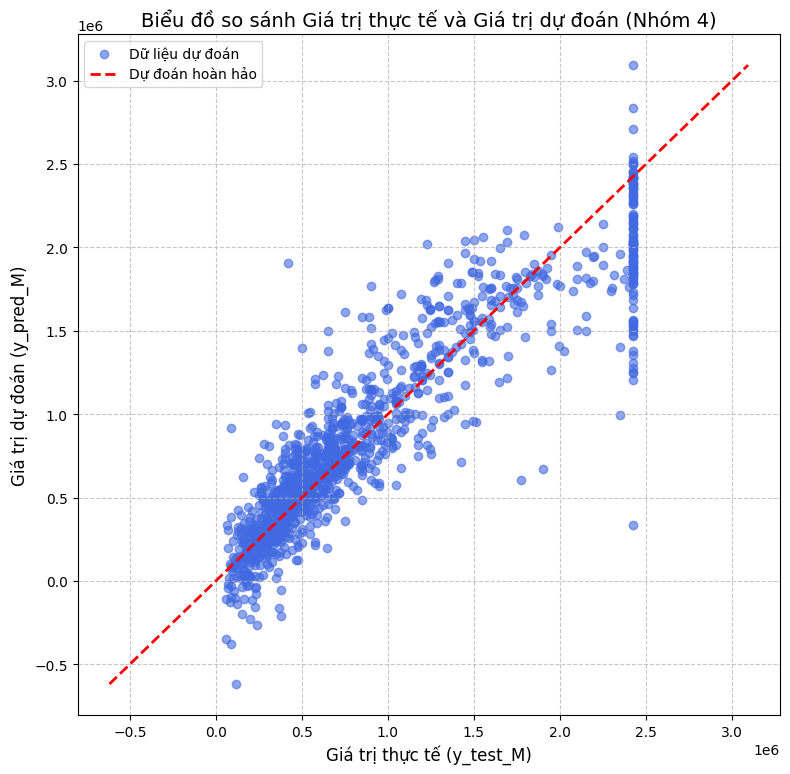

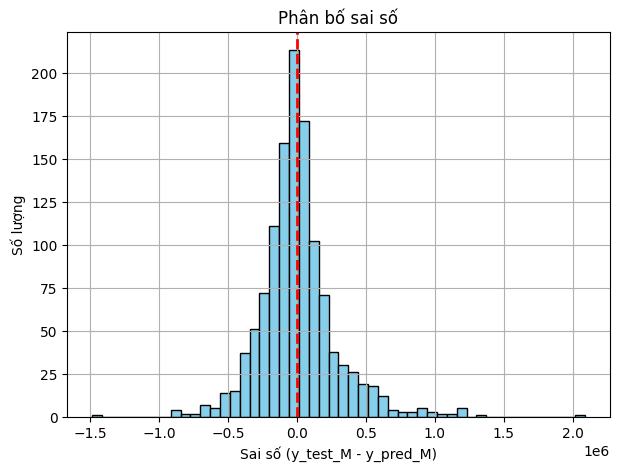


--- THỐNG KÊ SAI SỐ ---
Sai số trung bình (MAE): 192836.1341820215
Sai số chuẩn (STD): 284595.89707745914
Sai số tối đa: 2089973.6323603755


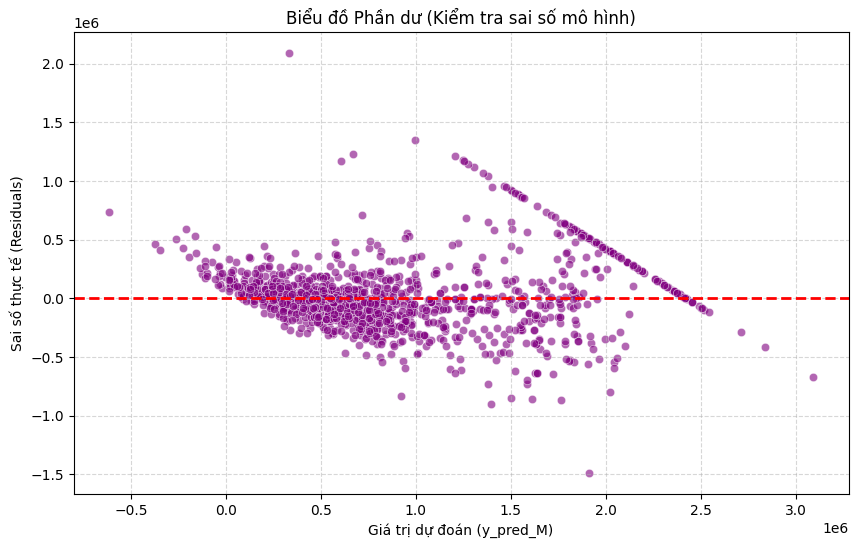

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PHẦN VẼ BIỂU ĐỒ ĐÁNH GIÁ MÔ HÌNH NHÓM 4
# ==========================================

# Biểu đồ so sánh Giá trị thực tế và Giá trị dự đoán
plt.figure(figsize=(8, 8))

# Trục x là y_test_M, Trục y là y_pred_M
plt.scatter(y_test_M, y_pred_M, alpha=0.6, color='royalblue', label='Dữ liệu dự đoán')

# Vẽ đường thẳng y = x (Đường lý tưởng: Giá trị dự đoán = Giá trị thực tế)
min_val = min(np.min(y_test_M), np.min(y_pred_M))
max_val = max(np.max(y_test_M), np.max(y_pred_M))

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Dự đoán hoàn hảo')

# Thêm tiêu đề và nhãn cho các trục
plt.title('Biểu đồ so sánh Giá trị thực tế và Giá trị dự đoán (Nhóm 4)', fontsize=14)
plt.xlabel('Giá trị thực tế (y_test_M)', fontsize=12)
plt.ylabel('Giá trị dự đoán (y_pred_M)', fontsize=12)

# Thêm chú thích và lưới cho dễ nhìn
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# --- Tính toán sai số ---
errors = y_test_M - y_pred_M 


# Histogram của sai số
plt.figure(figsize=(7,5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel("Sai số (y_test_M - y_pred_M)")
plt.ylabel("Số lượng")
plt.title("Phân bố sai số")
plt.grid(True)
plt.show()


# Một số thống kê sai số
print("\n--- THỐNG KÊ SAI SỐ ---")
print("Sai số trung bình (MAE):", np.mean(np.abs(errors)))
print("Sai số chuẩn (STD):", np.std(errors))
print("Sai số tối đa:", np.max(np.abs(errors)))


# Biểu đồ phần dư (Residual Plot)
plt.figure(figsize=(10, 6))
# Dùng y_pred_M cho trục x và errors (chính là phần dư) cho trục y
sns.scatterplot(x=y_pred_M, y=errors, alpha=0.6, color='purple')

# Vẽ đường cơ sở 0
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Biểu đồ Phần dư (Kiểm tra sai số mô hình)')
plt.xlabel('Giá trị dự đoán (y_pred_M)')
plt.ylabel('Sai số thực tế (Residuals)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()